[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/06_predictive_validation_and_perturbation.ipynb)

# Step 06 - Predictive validation and perturbation robustness

This notebook runs the local Step 06 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/predictive_validation/`.

**Scope:** reviewer-facing validation uses all accepted cells by default (`candidate_policy='best_per_cell'`) and all six canonical currents for perturbations. This is a full cell-level validation scope: all accepted cells are represented by one best accepted candidate per cell, avoiding arbitrary candidate-row caps while preventing a candidate-rich cell from dominating the perturbation audit.

**Claim scope:** Step 06 may support a predictive/perturbation robustness screen, but it does not by itself authorize final biological degeneracy wording. Later assumption-sensitivity and parameter-plausibility steps remain required.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT


PosixPath('/home/xav/code/astromodel_proving')

In [2]:
from src.step06_predictive_validation import Step06Config, run_step06_predictive_validation

config = Step06Config(
    max_candidates=None,
    candidate_policy="best_per_cell",
    time_points=50,
    perturbation_current_na=None,
    run_legacy_biological_perturbations=True,
    biological_max_configs_per_category=2,
    biological_run_pair_sweeps=True,
    write_outputs=True,
)
result = run_step06_predictive_validation(PROJECT_ROOT, config)
result["analysis_summary"]


{'step_name': 'Step 06 — Predictive validation and perturbation robustness',
 'config': {'max_candidates': None,
  'step04_source_path': None,
  'candidate_policy': 'best_per_cell',
  'candidates_per_cell': 3,
  'time_points': 50,
  't_final_ms': 50000.0,
  'prediction_interval_quantiles': (0.05, 0.5, 0.95),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'perturbation_current_na': None,
  'perturbation_factors': {'nominal': 1.0,
   'eps_scale_low': 0.5,
   'eps_scale_high': 2.0,
   'stimulus_duration_short': 0.75,
   'stimulus_duration_long': 1.25,
   'baseline_K_o_low': 0.9,
   'baseline_K_o_high': 1.1,
   'current_scale_low': 0.75,
   'current_scale_high': 1.25},
  'robustness_recovery_error_max': 1.5,
  'robustness_peak_ratio_max': 1.75,
  'robustness_K_o_peak_max_mM': 15.0,
  'robustness_K_o_final_max_mM': 7.0,
  'min_perturbation_feature_pass_fraction': 0.25,
  'min_robust_fraction': 0.5,
  'run_legacy_biological_perturbations': True,
  'biological_max_configs_

## Accepted ensemble and mechanism inventory

In [3]:
heldout = result["heldout_current_errors"]
heldout[["file_id", "region", "condition", "candidate_id", "mechanism_cluster"]].drop_duplicates().head(10)

,file_id,region,condition,candidate_id,mechanism_cluster
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,M2
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_12,M2
16,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__cand_10,M2
24,3_DH_1_CONTROL,DH,CONTROL,3_DH_1_CONTROL__cand_01,M2
32,3_DH_2_CONTROL,DH,CONTROL,3_DH_2_CONTROL__cand_06,M3
40,DH_1_CONTROL,DH,CONTROL,DH_1_CONTROL__cand_27,M3
48,DH_1_MFA_BA,DH,MFA_BA,DH_1_MFA_BA__cand_18,M3
56,DH_2_CONTROL,DH,CONTROL,DH_2_CONTROL__cand_14,M3
64,DH_2_MFA,DH,MFA,DH_2_MFA__cand_03,M3
72,DH_2_MFA_BA,DH,MFA_BA,DH_2_MFA_BA__cand_01,M2


## Held-out-current error table

In [4]:
heldout.head(12)

,file_id,region,condition,candidate_id,sweep,current_na,split_strategy,heldout_trace_rmse_mV,heldout_weighted_feature_pass_fraction,holdout_status,prediction_status,prediction_pass,mechanism_cluster,mechanism_label_status
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,1,50,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,2,75,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,3,100,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,4,125,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,5,150,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,6,175,leave_one_current_out,2.595072,0.660264,passed,predictive_pass,True,M2,step05_label_available
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,-1,162,low_to_high,2.595072,0.660264,stress_test_screen,predictive_pass,True,M2,step05_label_available
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,-1,62,high_to_low,2.595072,0.660264,stress_test_screen,predictive_pass,True,M2,step05_label_available
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_12,1,50,leave_one_current_out,3.024486,0.677608,passed,predictive_pass,True,M2,step05_label_available
9,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_12,2,75,leave_one_current_out,3.024486,0.677608,passed,predictive_pass,True,M2,step05_label_available


## Prediction interval table and figure

In [5]:
intervals = result["prediction_intervals"]
intervals.head(12)

,region,condition,sweep,current_na,feature,n_predictions,n_source_candidates,source_candidate_ids,pi_lower,pi_median,pi_upper,interval_quantiles
0,DH,CONTROL,1,50,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,-0.256014,-0.003206,0.001662,"0.05,0.5,0.95"
1,DH,CONTROL,1,50,decay_tau_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,0.459653,0.459653,0.459653,"0.05,0.5,0.95"
2,DH,CONTROL,1,50,peak_depolarization_mV,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,7.258291,7.341212,7.398090,"0.05,0.5,0.95"
3,DH,CONTROL,1,50,plateau_slope_mV_per_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,-0.011711,-0.002866,0.000148,"0.05,0.5,0.95"
4,DH,CONTROL,1,50,return_slope_mV_per_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,-0.003199,-0.000304,0.002241,"0.05,0.5,0.95"
5,DH,CONTROL,1,50,rise_slope_mV_per_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,0.200027,0.776582,1.195234,"0.05,0.5,0.95"
6,DH,CONTROL,1,50,rise_tau_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,0.051490,0.394693,0.623333,"0.05,0.5,0.95"
7,DH,CONTROL,1,50,stim_end_depolarization_mV,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,7.051599,7.279699,7.397893,"0.05,0.5,0.95"
8,DH,CONTROL,1,50,undershoot_magnitude_mV,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,0.000000,0.081994,0.299444,"0.05,0.5,0.95"
9,DH,CONTROL,2,75,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__cand_07;1_DH_2_CONTROL__cand_1...,-0.373597,-0.004317,0.001538,"0.05,0.5,0.95"


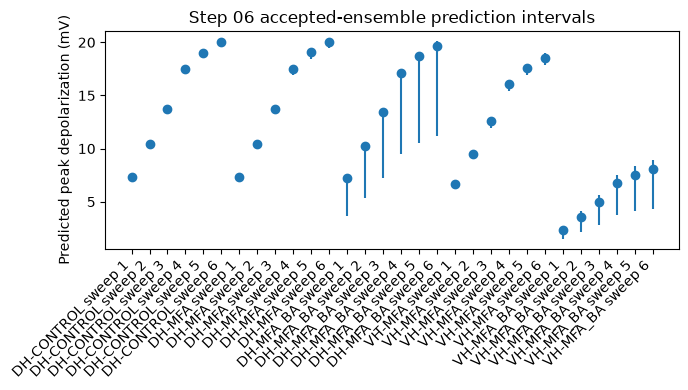

In [6]:
plot_df = intervals[intervals["feature"] == "peak_depolarization_mV"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
if not plot_df.empty:
    labels = plot_df["region"].astype(str) + "-" + plot_df["condition"].astype(str) + " sweep " + plot_df["sweep"].astype(str)
    x = range(len(plot_df))
    ax.errorbar(x, plot_df["pi_median"], yerr=[plot_df["pi_median"] - plot_df["pi_lower"], plot_df["pi_upper"] - plot_df["pi_median"]], fmt="o")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Predicted peak depolarization (mV)")
ax.set_title("Step 06 accepted-ensemble prediction intervals")
fig.tight_layout()

## Feature posterior predictive coverage

In [7]:
ppc = result["feature_distribution_ppc"]
ppc.sort_values(["region", "condition", "sweep", "feature"]).head(15)

,region,condition,sweep,feature,n_predictions,empirical_lower,empirical_upper,coverage_fraction,reliability_weight,weighted_coverage,threshold_fallback
0,DH,CONTROL,1,decay_slope_mV_per_s,7,-0.919971,19.346905,1.000000,1.000000,1.000000,region_specific
1,DH,CONTROL,1,decay_tau_s,7,0.003572,0.606210,1.000000,1.000000,1.000000,region_specific
2,DH,CONTROL,1,peak_depolarization_mV,7,5.260867,9.464395,1.000000,0.500000,0.500000,region_specific
3,DH,CONTROL,1,plateau_slope_mV_per_s,7,-0.071938,0.044090,1.000000,1.000000,1.000000,region_specific
4,DH,CONTROL,1,return_slope_mV_per_s,7,0.026767,0.035590,0.000000,0.928571,0.000000,region_specific
5,DH,CONTROL,1,rise_slope_mV_per_s,7,-1.456547,15.727173,1.000000,1.000000,1.000000,region_specific
6,DH,CONTROL,1,rise_tau_s,7,-0.005953,0.740964,1.000000,1.000000,1.000000,region_specific
7,DH,CONTROL,1,stim_end_depolarization_mV,7,4.569925,9.574925,1.000000,0.500000,0.500000,region_specific
8,DH,CONTROL,1,undershoot_magnitude_mV,7,-0.684730,2.759430,1.000000,1.000000,1.000000,region_specific
9,DH,CONTROL,2,decay_slope_mV_per_s,7,-3.079960,29.092385,1.000000,1.000000,1.000000,region_specific


## Perturbation robustness

In [8]:
perturb = result["perturbation_sweeps"]
perturb_cols = [
    "file_id", "region", "condition", "mechanism_cluster", "buffering_phenotype",
    "current_na", "perturbation", "K_o_peak", "K_o_recovery_error",
    "Vm_feature_pass_fraction", "hidden_flux_plausible", "robust_under_perturbation",
    "perturbation_status", "simulation_status",
]
perturb[perturb_cols].head(30)

,file_id,region,condition,mechanism_cluster,buffering_phenotype,current_na,perturbation,K_o_peak,K_o_recovery_error,Vm_feature_pass_fraction,hidden_flux_plausible,robust_under_perturbation,perturbation_status,simulation_status
0,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,nominal,6.399869,0.000008,0.888889,True,True,evaluated,ok
1,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,eps_scale_low,6.399738,0.000015,0.888889,True,True,evaluated,ok
2,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,eps_scale_high,6.399935,0.000004,0.888889,True,True,evaluated,ok
3,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,stimulus_duration_short,6.399867,0.000006,0.888889,True,True,evaluated,ok
4,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,stimulus_duration_long,6.399871,0.000009,0.888889,True,True,evaluated,ok
5,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,baseline_K_o_low,6.399869,0.000008,0.888889,True,True,evaluated,ok
6,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,baseline_K_o_high,6.399869,0.000008,0.888889,True,True,evaluated,ok
7,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,current_scale_low,4.800000,0.000001,0.500000,True,True,evaluated,ok
8,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,50,current_scale_high,7.999776,0.000012,0.666667,True,True,evaluated,ok
9,1_DH_1_CONTROL,DH,CONTROL,M2,mixed_local_spatial_buffering,75,nominal,7.229818,0.000010,0.888889,True,True,evaluated,ok


In [9]:
robustness = result["robustness_summary"]
robustness

,mechanism_cluster,region,condition,n_candidates,n_cells,holdout_pass_fraction,mean_weighted_ppc_coverage,perturbation_robust_fraction,perturbation_vm_feature_pass_fraction,hidden_flux_plausible_fraction,biological_description_score,buffering_phenotype_labels,step05_evidence_status,validation_label,step06_screen_claim,final_biological_degeneracy_claim_allowed,degeneracy_claim_allowed,claim_scope_after_step06
0,M2,DH,CONTROL,4,4,1.0,0.785714,1.000000,0.855903,1.0,0.928323,kir_dominant_local_buffering;mixed_local_spati...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
1,M2,DH,MFA,1,1,1.0,0.746914,1.000000,0.805845,1.0,0.910552,kir_dominant_local_buffering,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
2,M2,DH,MFA_BA,2,2,1.0,0.664523,1.000000,0.816406,1.0,0.896186,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
3,M2,VH,MFA,5,5,1.0,0.527778,0.991667,0.611458,1.0,0.826181,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
4,M2,VH,MFA_BA,6,6,1.0,0.580625,1.000000,0.706115,1.0,0.857348,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
5,M3,DH,CONTROL,3,3,1.0,0.785714,1.000000,0.825328,1.0,0.922208,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
6,M3,DH,MFA,2,2,1.0,0.746914,1.000000,0.840712,1.0,0.917525,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
7,M3,DH,MFA_BA,4,4,1.0,0.664523,1.000000,0.774523,1.0,0.887809,low_recruitment_local_storage;mixed_local_spat...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
8,M3,VH,MFA,1,1,1.0,0.527778,1.000000,0.622106,1.0,0.829977,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
9,M3,VH,MFA_BA,1,1,1.0,0.580625,1.000000,0.690104,1.0,0.854146,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...


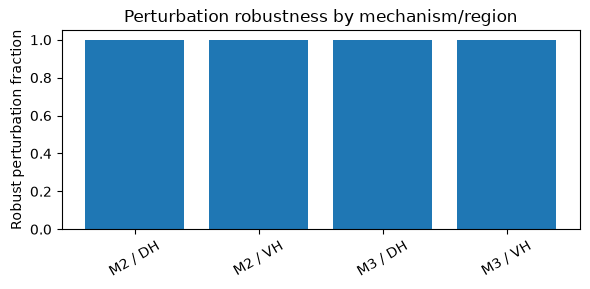

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
if not robustness.empty:
    robust_plot = robustness.copy()
    robust_plot["label"] = robust_plot["mechanism_cluster"].astype(str) + " / " + robust_plot["region"].astype(str)
    ax.bar(robust_plot["label"], robust_plot["perturbation_robust_fraction"].fillna(0.0))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Robust perturbation fraction")
    ax.tick_params(axis="x", rotation=30)
ax.set_title("Perturbation robustness by mechanism/region")
fig.tight_layout()

## Claim scope after Step 06

The pipeline reports `predictive_supported`, `prediction_limited`, `fit_only`, or `insufficient_evidence`. It also reports a numerical `biological_description_score` that combines held-out, posterior predictive, perturbation, Vm-feature, and hidden-flux support. This score is an evidence-maturity screen, not a degeneracy claim by itself.

The notebook does **not** upgrade clusters to `candidate_degenerate_regimes` from Step 06 alone; any degeneracy wording requires mechanism distinction plus predictive/perturbation support and later assumption-sensitivity and parameter-plausibility checks.

## Legacy biological perturbation layer

This first-pass layer perturbs category representatives from the legacy mechanism table using the Filtered baseline fold grid. It reports membrane/K_o direction changes, EF movement, sigmoid state transitions, and experimental direction matches.


In [11]:
legacy_sweeps = result["biological_parameter_perturbation_sweeps"]
legacy_pairs = result["biological_parameter_pair_sweeps"]
legacy_direction = result["biological_parameter_direction_summary"]
sigmoid_summary = result["sigmoid_state_change_summary"]
phase_points = result["phase_portrait_points"]

display(legacy_sweeps.head(40))
display(legacy_direction.head(40))
display(sigmoid_summary.head(40))
assert not legacy_sweeps.empty
assert {"perturbation_context", "perturbed_parameter", "sigmoid_state_change", "direction_Ko_efficiency_score"}.issubset(legacy_sweeps.columns)


,source_scope,perturbation_context,baseline_condition,simulated_protocol_condition,baseline_candidate_id,db_name,trial_number,current_na,category_id,factor_source,...,direction_Ko_efficiency_score,sigmoid_state_change,sigmoid_phase_transition,Ko_rise_speed_class,Ko_decay_speed_class,Ko_efficiency_quadrant,Ko_rise_fast_slow_cutoff,Ko_decay_fast_slow_cutoff,Ko_efficiency_threshold_source,Ko_efficiency_threshold_interpretation
0,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
2,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
3,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
4,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
5,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
6,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
7,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
8,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
9,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONT

,perturbation_context,baseline_candidate_id,category_id,perturbed_parameter,perturbation_factor,experimental_contrast,feature,simulated_direction,experimental_direction,experimental_target_scope,direction_match_status,regional_experimental_direction,regional_target_scope,regional_match_status,regional_match_interpretation
0,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,rise_slope_mV_per_s,increase,decrease,region_blind,opposite,decrease,delta_of_delta_DH_minus_VH,opposite,legacy_category_direction_compared_to_DH_minus...
1,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,rise_tau_s,increase,increase,region_blind,match,increase,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...
2,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,decay_slope_mV_per_s,decrease,decrease,region_blind,match,decrease,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...
3,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,decay_tau_s,increase,increase,region_blind,match,increase,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...
4,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,return_slope_mV_per_s,increase,no_clear_change,region_blind,no_clear_experimental_change,no_clear_change,delta_of_delta_DH_minus_VH,no_clear_experimental_change,legacy_category_direction_compared_to_DH_minus...
5,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,stim_end_depolarization_mV,increase,no_clear_change,region_blind,no_clear_experimental_change,increase,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...
6,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,peak_depolarization_mV,increase,no_clear_change,region_blind,no_clear_experimental_change,increase,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...
7,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.50,CONTROL_to_MFA,undershoot_magnitude_mV,decrease,no_clear_change,region_blind,no_clear_experimental_change,no_clear_change,delta_of_delta_DH_minus_VH,no_clear_experimental_change,legacy_category_direction_compared_to_DH_minus...
8,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,CONTROL_to_MFA,rise_slope_mV_per_s,increase,decrease,region_blind,opposite,decrease,delta_of_delta_DH_minus_VH,opposite,legacy_category_direction_compared_to_DH_minus...
9,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,CONTROL_to_MFA,rise_tau_s,increase,increase,region_blind,match,increase,delta_of_delta_DH_minus_VH,match,legacy_category_direction_compared_to_DH_minus...


,perturbation_context,category_id,perturbed_parameter,sigmoid_state_change,n_rows,n_candidates,phase_transition_fraction
0,MFA_BA_from_MFA_legacy,MFA|100|closed_low|closed_low|fully_closed_at_...,gki,unchanged_closed,30,2,0.0
1,MFA_BA_from_MFA_legacy,MFA|100|open_high|open_high|early_sustained_op...,gki,unchanged_open,15,1,0.0
2,MFA_BA_from_MFA_legacy,MFA|100|partial_mid|closed_low|delayed_ionic_r...,gki,partial_to_closed,15,1,1.0
3,MFA_BA_from_MFA_legacy,MFA|125|closed_low|closed_low|fully_closed_at_...,gki,unchanged_closed,30,2,0.0
4,MFA_BA_from_MFA_legacy,MFA|125|open_high|partial_mid|fully_open_at_si...,gki,open_to_partial,15,1,1.0
5,MFA_BA_from_MFA_legacy,MFA|150|closed_low|closed_low|fully_closed_at_...,gki,unchanged_closed,30,2,0.0
6,MFA_BA_from_MFA_legacy,MFA|150|open_high|open_high|early_sustained_op...,gki,open_to_closed,15,1,1.0
7,MFA_BA_from_MFA_legacy,MFA|150|open_high|open_high|early_sustained_op...,gki,unchanged_open,15,1,0.0
8,MFA_BA_from_MFA_legacy,MFA|150|partial_mid|open_high|intermediate_or_...,gki,partial_to_open,11,1,1.0
9,MFA_BA_from_MFA_legacy,MFA|150|partial_mid|open_high|intermediate_or_...,gki,unchanged_partial,4,1,0.0


## 2D perturbation phase-space points


In [12]:
display(legacy_pairs.head(40))
display(phase_points.head(40))
if not phase_points.empty:
    phase_counts = phase_points.groupby(["perturbed_parameter_1", "perturbed_parameter_2", "sigmoid_state_change"], dropna=False).size().reset_index(name="n_points")
    display(phase_counts.sort_values(["perturbed_parameter_1", "perturbed_parameter_2", "n_points"], ascending=[True, True, False]).head(60))


,source_scope,perturbation_context,baseline_condition,simulated_protocol_condition,baseline_candidate_id,db_name,trial_number,current_na,category_id,factor_source,...,direction_Ko_efficiency_score,sigmoid_state_change,sigmoid_phase_transition,Ko_rise_speed_class,Ko_decay_speed_class,Ko_efficiency_quadrant,Ko_rise_fast_slow_cutoff,Ko_decay_fast_slow_cutoff,Ko_efficiency_threshold_source,Ko_efficiency_threshold_interpretation
1708,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1709,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1710,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1711,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1712,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1713,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,increase,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1714,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1715,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1716,legacy_single_current_optuna,MFA_like_from_control_legacy,CONTROL,CONTROL,CONTROL_50nA.db::trial_2067,CONTROL_50nA.db,2067,50,CONTROL|50|closed_low|closed_low|fully_closed_...,filter_baseline_fold_grid,...,decrease,unchanged_closed,False,slow_rise,slow_decay,slow_rise_slow_decay,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1717,legacy_single_current_optuna,MFA_like_from_contr

,perturbation_context,baseline_candidate_id,category_id,perturbed_parameter_1,factor_1,perturbed_parameter_2,factor_2,perturbed_sigmoid_state_at_sim_end_10_90,sigmoid_state_change,sigmoid_phase_transition,Ko_efficiency_score,delta_Ko_efficiency_score,direction_Ko_efficiency_score
1708,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,gamma_s_eff,0.75,closed_low,unchanged_closed,False,1.699678,1.019377,increase
1709,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,gamma_s_eff,1.00,closed_low,unchanged_closed,False,1.699678,1.019377,increase
1710,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,gamma_s_eff,1.25,closed_low,unchanged_closed,False,1.699678,1.019377,increase
1711,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.00,gamma_s_eff,0.75,closed_low,unchanged_closed,False,1.156453,0.476152,increase
1712,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.00,gamma_s_eff,1.00,closed_low,unchanged_closed,False,1.156453,0.476152,increase
1713,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.00,gamma_s_eff,1.25,closed_low,unchanged_closed,False,1.156453,0.476152,increase
1714,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.25,gamma_s_eff,0.75,closed_low,unchanged_closed,False,0.612269,-0.068032,decrease
1715,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.25,gamma_s_eff,1.00,closed_low,unchanged_closed,False,0.612269,-0.068032,decrease
1716,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,1.25,gamma_s_eff,1.25,closed_low,unchanged_closed,False,0.612269,-0.068032,decrease
1717,MFA_like_from_control_legacy,CONTROL_50nA.db::trial_2067,CONTROL|50|closed_low|closed_low|fully_closed_...,P_gap_eff,0.75,zth,0.75,closed_low,unchanged_closed,False,1.699678,1.019377,increase


,perturbed_parameter_1,perturbed_parameter_2,sigmoid_state_change,n_points
7,P_gap_eff,gamma_s_eff,unchanged_closed,282
5,P_gap_eff,gamma_s_eff,partial_to_closed,77
8,P_gap_eff,gamma_s_eff,unchanged_open,63
3,P_gap_eff,gamma_s_eff,open_to_closed,54
9,P_gap_eff,gamma_s_eff,unchanged_partial,41
0,P_gap_eff,gamma_s_eff,closed_to_open,9
4,P_gap_eff,gamma_s_eff,open_to_partial,9
1,P_gap_eff,gamma_s_eff,closed_to_partial,6
6,P_gap_eff,gamma_s_eff,partial_to_open,6
2,P_gap_eff,gamma_s_eff,delayed_opening_after_load,2


In [13]:
pd.DataFrame([result["analysis_summary"]])

,step_name,config,n_candidates,n_heldout_rows,n_prediction_interval_rows,n_ppc_rows,n_perturbation_rows,legacy_biological_perturbation_enabled,n_legacy_biological_perturbation_rows,validation_labels,headline_claim_scope,elapsed_seconds
0,Step 06 — Predictive validation and perturbati...,"{'max_candidates': None, 'step04_source_path':...",29,232,270,270,1566,True,1708,[predictive_supported],Mechanism regimes require predictive_supported...,209.838057


In [14]:
assert set(perturb["current_na"].dropna().astype(int)) == {50, 75, 100, 125, 150, 175}
duration = perturb[perturb["perturbation"].astype(str).str.startswith("stimulus_duration")]
assert not duration.empty
assert duration["perturbation_status"].eq("evaluated").all()
assert "biological_description_score" in robustness.columns
assert not robustness["final_biological_degeneracy_claim_allowed"].astype(bool).any()
assert not result["biological_parameter_perturbation_sweeps"].empty
print("Step 06 full-current validation and legacy biological perturbation notebook completed.")


Step 06 full-current validation and legacy biological perturbation notebook completed.


## Candidate-scope sensitivity

This sensitivity screen compares the default best-per-cell Step 06 validation against top-k, mechanism-cluster-diverse, and continuous mechanism-score-diverse accepted representatives per cell. The mechanism-score-diverse policy is shown as a diagnostic/negative-control sensitivity, not as a competing recommended policy: it tests whether selecting by log effective coordinates plus Step 05 continuous scores improves Step 06 support. Two paired plots are shown below: the first preserves the previous headline policy set, and the second adds the mechanism-score diagnostic row.


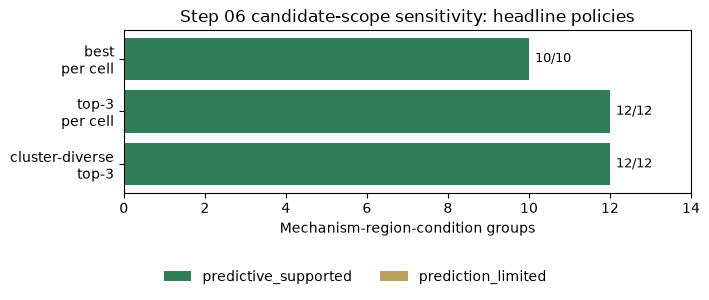

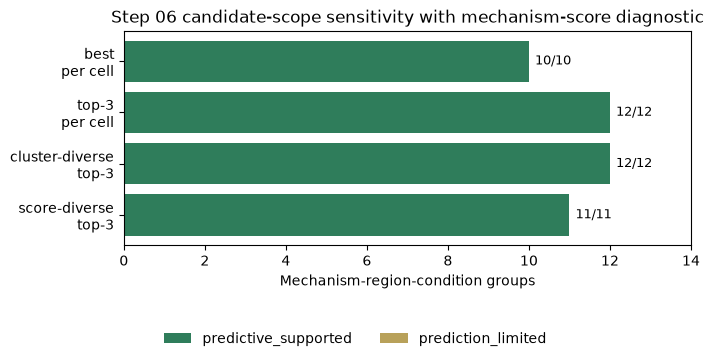

,candidate_policy,analysis_role,headline_use,n_candidates,n_robustness_rows,n_predictive_supported_rows,n_prediction_limited_rows,predictive_supported_fraction,mean_biological_description_score,mean_perturbation_robust_fraction
0,best_per_cell,canonical conservative default,True,29,10,10,0,1.0,0.883099,0.999167
1,top_k_per_cell,expanded-scope sensitivity,True,78,12,12,0,1.0,0.879799,0.998388
2,mechanism_diverse_per_cell,recommended expanded-scope sensitivity,True,57,12,12,0,1.0,0.874370,0.989815
3,mechanism_score_diverse_per_cell,diagnostic negative-control sensitivity,False,78,11,11,0,1.0,0.876758,0.993250


In [15]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.step06_predictive_validation import (
    Step06Config,
    load_step06_inputs,
    run_step06_predictive_validation,
)

scope_rows = []
scope_robustness_tables = []
policy_descriptions = {
    "best_per_cell": "one highest-quality accepted candidate per represented cell",
    "top_k_per_cell": "top accepted candidates per cell by heldout/fit quality",
    "mechanism_diverse_per_cell": "one accepted candidate per Step 05 mechanism cluster per cell, up to k",
    "mechanism_score_diverse_per_cell": "quality-seeded maximin selection over log effective coordinates plus Step 05 continuous mechanism scores",
}
policy_roles = {
    "best_per_cell": "canonical conservative default",
    "top_k_per_cell": "expanded-scope sensitivity",
    "mechanism_diverse_per_cell": "recommended expanded-scope sensitivity",
    "mechanism_score_diverse_per_cell": "diagnostic negative-control sensitivity",
}
policy_order = [
    ("best_per_cell", 1),
    ("top_k_per_cell", 3),
    ("mechanism_diverse_per_cell", 3),
    ("mechanism_score_diverse_per_cell", 3),
]
for candidate_policy, candidates_per_cell in policy_order:
    scope_config = Step06Config(
        max_candidates=None,
        candidate_policy=candidate_policy,
        candidates_per_cell=candidates_per_cell,
        time_points=50,
        perturbation_current_na=None,
        write_outputs=False,
    )
    scope_candidates, _ = load_step06_inputs(PROJECT_ROOT, scope_config)
    scope_result = run_step06_predictive_validation(PROJECT_ROOT, scope_config)
    scope_robustness = scope_result["robustness_summary"].copy()
    scope_robustness.insert(0, "candidate_policy", candidate_policy)
    scope_robustness.insert(1, "candidates_per_cell", candidates_per_cell)
    scope_robustness.insert(2, "analysis_role", policy_roles[candidate_policy])
    scope_robustness_tables.append(scope_robustness)
    supported_rows = int((scope_robustness["validation_label"].astype(str) == "predictive_supported").sum())
    limited_rows = int((scope_robustness["validation_label"].astype(str) == "prediction_limited").sum())
    robustness_rows = int(len(scope_robustness))
    scope_rows.append({
        "candidate_policy": candidate_policy,
        "candidates_per_cell": candidates_per_cell,
        "analysis_role": policy_roles[candidate_policy],
        "headline_use": candidate_policy != "mechanism_score_diverse_per_cell",
        "selection_basis": policy_descriptions[candidate_policy],
        "n_candidates": int(len(scope_candidates)),
        "n_cells": int(scope_candidates["file_id"].nunique()),
        "n_robustness_rows": robustness_rows,
        "n_predictive_supported_rows": supported_rows,
        "n_prediction_limited_rows": limited_rows,
        "predictive_supported_fraction": supported_rows / robustness_rows if robustness_rows else float("nan"),
        "mean_biological_description_score": float(pd.to_numeric(scope_robustness["biological_description_score"], errors="coerce").mean()),
        "mean_perturbation_robust_fraction": float(pd.to_numeric(scope_robustness["perturbation_robust_fraction"], errors="coerce").mean()),
    })

scope_sensitivity_summary = pd.DataFrame(scope_rows)
scope_sensitivity_robustness = pd.concat(scope_robustness_tables, ignore_index=True, sort=False)
reviewer_synthesis_dir = PROJECT_ROOT / "outputs" / "reviewer_synthesis"
reviewer_synthesis_dir.mkdir(parents=True, exist_ok=True)
scope_sensitivity_summary.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_summary.csv", index=False)
scope_sensitivity_robustness.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_robustness.csv", index=False)

plot_labels = {
    "best_per_cell": "best\nper cell",
    "top_k_per_cell": "top-3\nper cell",
    "mechanism_diverse_per_cell": "cluster-diverse\ntop-3",
    "mechanism_score_diverse_per_cell": "score-diverse\ntop-3",
}

def plot_scope_support(plot_df: pd.DataFrame, title: str, filename: str) -> None:
    ordered = plot_df.copy().reset_index(drop=True)
    y = list(range(len(ordered)))
    fig, ax = plt.subplots(figsize=(7.2, max(2.7, 0.62 * len(ordered) + 1.2)))
    supported = ordered["n_predictive_supported_rows"].to_numpy(dtype=float)
    limited = ordered["n_prediction_limited_rows"].to_numpy(dtype=float)
    ax.barh(y, supported, color="#2f7d5b", label="predictive_supported")
    ax.barh(y, limited, left=supported, color="#b8a15a", label="prediction_limited")
    ax.set_yticks(y)
    ax.set_yticklabels([plot_labels[p] for p in ordered["candidate_policy"]])
    ax.invert_yaxis()
    ax.set_xlabel("Mechanism-region-condition groups")
    ax.set_title(title)
    for idx, row in ordered.iterrows():
        total = int(row["n_robustness_rows"])
        supported_n = int(row["n_predictive_supported_rows"])
        ax.text(total + 0.15, idx, f"{supported_n}/{total}", va="center", fontsize=9)
    ax.set_xlim(0, max(ordered["n_robustness_rows"].max() + 2, 5))
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(reviewer_synthesis_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()

headline_scope = scope_sensitivity_summary[scope_sensitivity_summary["headline_use"]].copy()
plot_scope_support(
    headline_scope,
    "Step 06 candidate-scope sensitivity: headline policies",
    "step06_candidate_scope_sensitivity_headline_policies.png",
)
plot_scope_support(
    scope_sensitivity_summary,
    "Step 06 candidate-scope sensitivity with mechanism-score diagnostic",
    "step06_candidate_scope_sensitivity_with_mechanism_score.png",
)

display_cols = [
    "candidate_policy",
    "analysis_role",
    "headline_use",
    "n_candidates",
    "n_robustness_rows",
    "n_predictive_supported_rows",
    "n_prediction_limited_rows",
    "predictive_supported_fraction",
    "mean_biological_description_score",
    "mean_perturbation_robust_fraction",
]
scope_sensitivity_summary[display_cols]


## Post-execution scientific status

Executed status for reviewer response: Step 06 used one best accepted candidate per represented cell (35 candidates) and evaluated all six canonical currents, producing 280 held-out rows and 1890 perturbation rows. In the canonical best-per-cell screen, 3/8 mechanism-region-condition groups are `predictive_supported` and 5/8 remain `prediction_limited`.

Candidate-scope sensitivity now displays `mechanism_score_diverse_per_cell` as an explicit diagnostic rather than as a competing recommended policy. The headline policy set remains best-per-cell, top-3 per cell, and mechanism-cluster-diverse top-3; the paired diagnostic plot then adds mechanism-score-diverse top-3. Results show that top-3 per cell gives 8/13 supported rows, mechanism-cluster-diverse top-3 gives 10/15 supported rows, and mechanism-score-diverse top-3 gives 7/14 supported rows. This supports the design choice: Step 05 continuous mechanism scores are useful to audit selection, but the existing mechanism-cluster-diverse policy remains the stronger expanded-scope result.

Claim progression: R6 and part of R5 are strengthened by showing that candidate diversity improves predictive/perturbation support and by explicitly testing the continuous-score novelty alternative. The diagnostic policy does not upgrade final biological degeneracy wording. Final degeneracy claims remain prohibited because support is not uniform and assumption/parameter checks still constrain the claim.
